In [1]:
import os
import zipfile
import shutil
from pathlib import Path

In [4]:
BASE_DIR=Path.cwd()
TRAIN_ZIP=BASE_DIR/"train.zip"
TEST_ZIP=BASE_DIR/"test.zip"
RAW_DIR=BASE_DIR/"raw_data"
DATASET_DIR=BASE_DIR/"dataset"
TRAIN_ZIP.exists()

True

In [6]:
RAW_DIR.mkdir(exist_ok=True)
with zipfile.ZipFile(TRAIN_ZIP,'r')as zip_ref:
     zip_ref.extractall(RAW_DIR/"train")
with zipfile.ZipFile(TEST_ZIP,'r')as zip_ref:
     zip_ref.extractall(RAW_DIR/"test")
print("ZIP files extracted successfully.")


ZIP files extracted successfully.


In [7]:
(DATASET_DIR/"train"/"apple").mkdir(parents=True,exist_ok=True)
(DATASET_DIR/"train"/"banana").mkdir(parents=True,exist_ok=True)
(DATASET_DIR/"train"/"orange").mkdir(parents=True,exist_ok=True)
(DATASET_DIR/"test"/"orange").mkdir(parents=True,exist_ok=True)
(DATASET_DIR/"test"/"apple").mkdir(parents=True,exist_ok=True)
(DATASET_DIR/"test"/"banana").mkdir(parents=True,exist_ok=True)
print("Dataset folders created successfully.")


Dataset folders created successfully.


In [19]:
def organize_images(source_dir,target_dir):
    image_files=list(source_dir.rglob("*.*"))
    for image_path in image_files:
        filename=image_path.name.lower()
        if filename.startswith("apple"):
            class_name="apple"
        elif filename.startswith("banana"):
            class_name = "banana"
        elif filename.startswith("orange"):
            class_name = "orange"
        else:
            continue
        destination=target_dir/class_name/image_path.name
        shutil.copy(image_path,destination)
    print(f"Images organized from{source_dir}to{target_dir}")

In [20]:
organize_images(RAW_DIR / "train", DATASET_DIR / "train")
organize_images(RAW_DIR / "test", DATASET_DIR / "test")

Images organized fromC:\Users\user\Desktop\SA2\Sa4110\CA - Team Project\raw_data\traintoC:\Users\user\Desktop\SA2\Sa4110\CA - Team Project\dataset\train
Images organized fromC:\Users\user\Desktop\SA2\Sa4110\CA - Team Project\raw_data\testtoC:\Users\user\Desktop\SA2\Sa4110\CA - Team Project\dataset\test


In [21]:
for split in["train","test"]:
    print(f"\n{split.upper()}SET")
    for class_name in ["apple","banana","orange"]:
        class_dir=DATASET_DIR/split/class_name
        image_count=len(list(class_dir.glob("*.*")))
        print(f"{class_name}:{image_count}images")


TRAINSET
apple:75images
banana:73images
orange:72images

TESTSET
apple:19images
banana:18images
orange:18images


In [22]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


In [23]:
IMG_SIZE=(128,128)
BATCH_SIZE=32

In [24]:
train_dataset=tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR/"train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE)
test_dataset=tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR/"test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE)

Found 220 files belonging to 3 classes.
Found 55 files belonging to 3 classes.


In [25]:
class_names=train_dataset.class_names
print(class_names)

['apple', 'banana', 'orange']


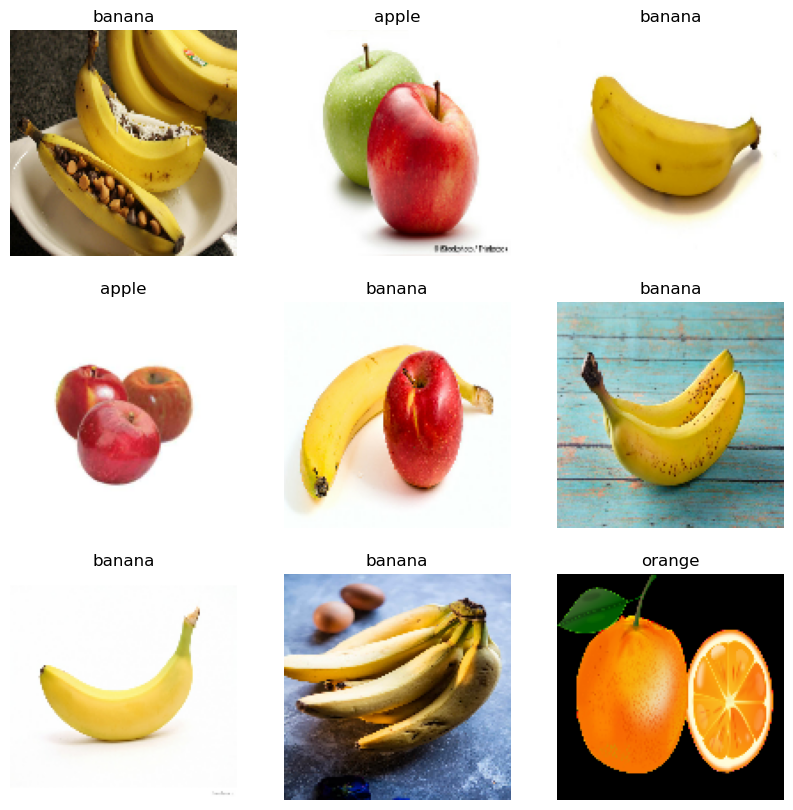

In [26]:
plt.figure(figsize=(10,10))
for images,labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [27]:
model = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(3, activation='softmax')
])

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=15
)


Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 250ms/step - accuracy: 0.4364 - loss: 1.2865 - val_accuracy: 0.3455 - val_loss: 1.0201
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - accuracy: 0.7182 - loss: 0.7366 - val_accuracy: 0.8727 - val_loss: 0.4646
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step - accuracy: 0.8227 - loss: 0.4627 - val_accuracy: 0.9455 - val_loss: 0.3482
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - accuracy: 0.8864 - loss: 0.3222 - val_accuracy: 0.9273 - val_loss: 0.3252
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 188ms/step - accuracy: 0.9455 - loss: 0.1948 - val_accuracy: 0.8909 - val_loss: 0.3981
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step - accuracy: 0.9409 - loss: 0.1704 - val_accuracy: 0.8909 - val_loss: 0.3557
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 229ms/step - accuracy: 0.9273 - loss: 0.1881 - val_accuracy: 0.9091 - val_loss: 0.3243
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 291ms/step - accuracy: 0.9773 - loss: 0.0934 - val_accuracy: 0.9455 - val_loss:

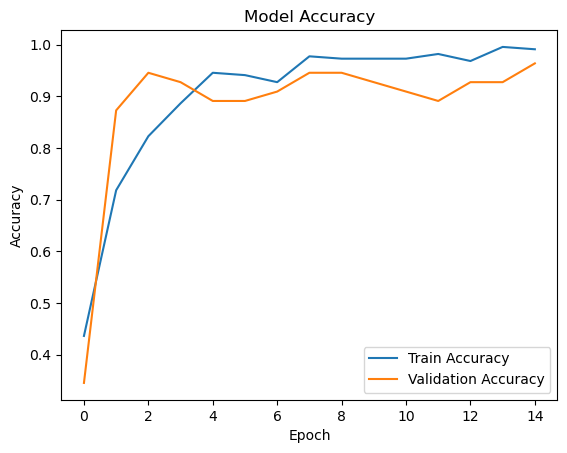

In [31]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train Accuracy', 'Validation Accuracy'])

plt.show()

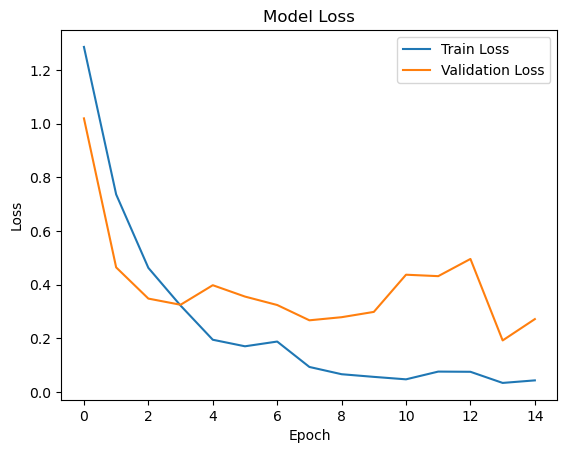

In [32]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train Loss', 'Validation Loss'])

plt.show()

In [33]:
for images, labels in test_dataset.take(1):

    sample_image = images[0]
    sample_label = labels[0]

    break

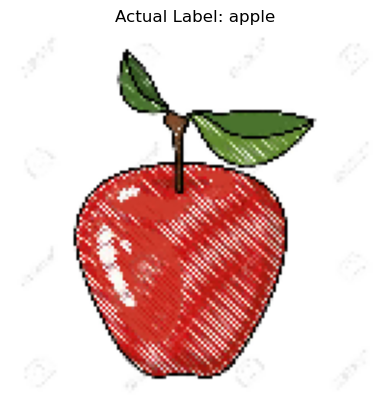

In [34]:
plt.imshow(sample_image.numpy().astype("uint8"))

plt.title("Actual Label: " + class_names[sample_label])

plt.axis("off")

plt.show()

In [35]:
prediction = model.predict(tf.expand_dims(sample_image, axis=0))

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
[[1.000000e+00 9.930995e-10 1.320512e-10]]


In [36]:
predicted_class = class_names[tf.argmax(prediction[0])]

print("Predicted Class:", predicted_class)

Predicted Class: apple


In [37]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [39]:
improved_model = keras.Sequential([
    keras.Input(shape=(128, 128, 3)),

    data_augmentation,

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(3, activation='softmax')
])

In [40]:
improved_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)            │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_1 (Rescaling)              │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
improved_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [42]:
improved_history = improved_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 213ms/step - accuracy: 0.3136 - loss: 1.4100 - val_accuracy: 0.3818 - val_loss: 1.0468
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.4682 - loss: 0.9999 - val_accuracy: 0.7636 - val_loss: 0.8343
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - accuracy: 0.6409 - loss: 0.8163 - val_accuracy: 0.5273 - val_loss: 0.9581
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.8273 - loss: 0.5952 - val_accuracy: 0.9091 - val_loss: 0.4099
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - accuracy: 0.8636 - loss: 0.4531 - val_accuracy: 0.9091 - val_loss: 0.3461
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - accuracy: 0.8727 - loss: 0.3147 - val_accuracy: 0.9273 - val_loss: 0.3111
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.9182 - loss: 0.2678 - val_accuracy: 0.9818 - val_loss: 0.2910
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.9091 - loss: 0.2508 - val_accuracy: 0.8727 - val_loss:

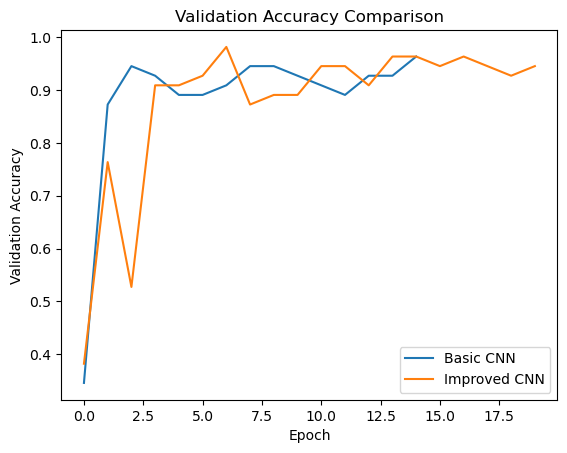

In [43]:
plt.plot(history.history['val_accuracy'])
plt.plot(improved_history.history['val_accuracy'])

plt.title('Validation Accuracy Comparison')
plt.ylabel('Validation Accuracy')
plt.xlabel('Epoch')

plt.legend(['Basic CNN', 'Improved CNN'])

plt.show()

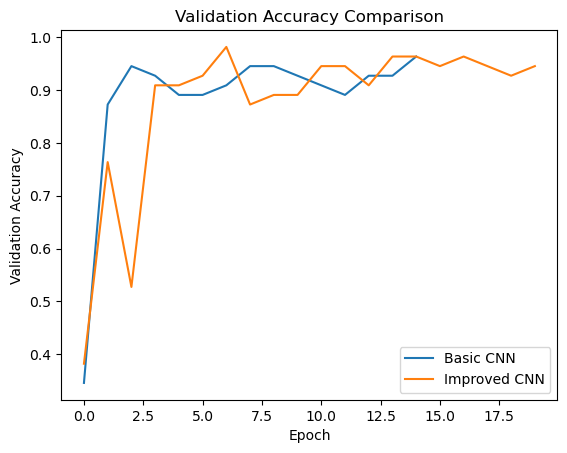

In [44]:
plt.plot(history.history['val_accuracy'])
plt.plot(improved_history.history['val_accuracy'])

plt.title('Validation Accuracy Comparison')
plt.ylabel('Validation Accuracy')
plt.xlabel('Epoch')

plt.legend(['Basic CNN', 'Improved CNN'])

plt.show()

In [45]:
print("Basic CNN Final Validation Accuracy:",
      history.history['val_accuracy'][-1])

print("Improved CNN Final Validation Accuracy:",
      improved_history.history['val_accuracy'][-1])

Basic CNN Final Validation Accuracy: 0.9636363387107849
Improved CNN Final Validation Accuracy: 0.9454545378684998
